# Кредитный скоринг (Альфа-Банк × МФТИ)

Задача - оценить вероятность дефолта клиента по его кредитной истории. Каждый клиент описан последовательностью кредитных продуктов с набором закодированных признаков и помесячной историей платежей. Качество измеряется метрикой ROC-AUC.

Решение построено как ансамбль из нескольких непохожих моделей. Часть из них работает с агрегированными признаками всей истории клиента, часть - напрямую с последовательностью продуктов. Предсказания моделей объединяются, а затем уточняются за счёт самостоятельной разметки тестовых данных. Обученные модели и их предсказания сохраняются, поэтому повторный проход переиспользует уже посчитанное.

## Подготовка окружения

Подключение библиотек и настройка вычислений на видеокарте.

In [1]:
import os
import gc
import glob
import json
import time
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as pads
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

DEVICE = 'cuda'
AMP_DTYPE = torch.bfloat16
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print('torch', torch.__version__, '|', torch.cuda.get_device_name(0))

torch 2.0.1+cu118 | NVIDIA A100-SXM4-80GB


## Параметры

Основные настройки обучения и ансамбля.

In [25]:
SEED = 42
BATCH = 8192
np.random.seed(SEED)
torch.manual_seed(SEED)

NN_FOLDS = 5
GBDT_FOLDS = 5
N_SEEDS = 1

PATIENCE = 5
MODEL_EPOCHS = {
    'gru': 10,
    'transformer': 15,
    'cnn': 18,
    'transformer_hier': 8,
}

EMA_DECAY = 0.999
EMA_EVERY = 4
VAL_SUBSAMPLE = 100_000

MAX_LEN = 50
D_MODEL = 256
GRU_LAYERS = 2
TF_LAYERS = 3
TF_FF = 1024
MAX_LR = 2e-3

USE_CACHE = True
CACHE_VERSION = 'v2'
SAVE_MODELS = True
RESUME = True
FINETUNE = False

PL_EPOCHS = 4
PL_POS_Q = 0.9
PL_NEG_Q = 0.99
PL_MAX_NEG_MULT = 5


MODEL_PARAMS = {
    'xgboost': {'learning_rate': 0.015199348301309814, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_lambda': 0.38234752246751863, 'gamma': 3.0592644736118975},
    'gru': {'d_model': 128, 'gru_layers': 1, 'dropout': 0.38056375658581343, 'max_lr': 0.0020898571378360426, 'weight_decay': 1.053746415699816e-06},
    'transformer': {'d_model': 128, 'tf_layers': 2, 'tf_ff': 1536, 'dropout': 0.07478766874466249, 'max_lr': 0.001173769209815432, 'weight_decay': 0.0001847793417351927},
    'cnn': {'d_model': 128, 'tcn_levels': 4, 'dropout': 0.12899315955145987, 'max_lr': 0.003478756568985834, 'weight_decay': 0.0001398005360250269},
    'transformer_hier': {'d_model': 192, 'hier_layers': 5, 'hier_hidden_mult': 3, 'dropout': 0.073378026190659, 'max_lr': 0.0028020568721807385, 'weight_decay': 0.0011277712372014764, 'grad_clip': 2.0, 'label_smooth': 0.04836599730858594},
}

print('BATCH', BATCH, '| фолды', NN_FOLDS, '| сиды', N_SEEDS, '| resume', RESUME)
print('finetune', FINETUNE, '| эпохи по моделям:', MODEL_EPOCHS)

BATCH 8192 | фолды 5 | сиды 1 | resume True
finetune False | эпохи по моделям: {'gru': 10, 'transformer': 15, 'cnn': 18, 'transformer_hier': 8}


## Расположение файлов

Исходные данные находятся рядом с ноутбуком. Здесь же задаются папки для сохранения моделей и промежуточных результатов; если предобработка уже сохранена, повторная подготовка не требуется.

In [3]:
OUT = os.getcwd()
SAVE_DIR = os.path.join(OUT, 'models')
CACHE_DIR = os.path.join(OUT, 'cache')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_KEYS = [
    'X_agg', 'X_test', 'y', 'ids_tr', 'ids_te',
    'tr_first', 'tr_cnt', 'tr_feats', 'tr_rn',
    'te_first', 'te_cnt', 'te_feats', 'te_rn',
]

def cache_path(name):
    return os.path.join(CACHE_DIR, f'{CACHE_VERSION}_{name}')

cache_ready = (
    USE_CACHE
    and os.path.exists(cache_path('meta.json'))
    and all(os.path.exists(cache_path(key + '.npy')) for key in CACHE_KEYS)
)

TRAIN = os.path.join(OUT, 'train_data.parquet')
TEST = os.path.join(OUT, 'test_data.parquet')
TGT = os.path.join(OUT, 'train_target.csv')
SUB = os.path.join(OUT, 'sample_submission.csv')

print('кэш:', 'есть' if cache_ready else 'нет', '| рабочая папка:', OUT)

кэш: есть | рабочая папка: /home/jupyter/alpha


## Предобработка данных

Функции для загрузки данных, построения агрегированных признаков по истории клиента и формирования последовательностей продуктов фиксированной длины.

In [4]:
def load_parquet(path):
    dataset = pads.dataset(path, format='parquet')
    columns = {}
    for name in dataset.schema.names:
        array = dataset.to_table(columns=[name]).column(0).combine_chunks()
        dtype = pa.int32() if name == 'id' else pa.int8()
        columns[name] = array.cast(dtype).to_numpy(zero_copy_only=False)
        del array
        gc.collect()
    frame = pd.DataFrame(columns)
    del columns
    gc.collect()
    return frame

In [5]:
def aggregate(df):
    df = df.copy()

    paym_cols = [c for c in df.columns if c.startswith('enc_paym_')]
    if paym_cols:
        df['n_bad_paym'] = (df[paym_cols].values >= 3).sum(1).astype(np.int16)

    overdue_cols = [c for c in ['pre_loans5', 'pre_loans530', 'pre_loans3060',
                                'pre_loans6090', 'pre_loans90'] if c in df.columns]
    if overdue_cols:
        df['tot_overdue'] = df[overdue_cols].sum(1).astype(np.int16)

    if 'pre_loans_outstanding' in df and 'pre_loans_credit_limit' in df:
        limit = df['pre_loans_credit_limit'].astype(np.float32) + 1
        df['util_ratio'] = (df['pre_loans_outstanding'] / limit).astype(np.float32)
    if 'pre_loans_next_pay_summ' in df and 'pre_loans_credit_limit' in df:
        limit = df['pre_loans_credit_limit'].astype(np.float32) + 1
        df['nextpay_ratio'] = (df['pre_loans_next_pay_summ'] / limit).astype(np.float32)

    flag_cols = [c for c in df.columns if c.startswith('is_zero') or c.endswith('_flag')]
    feat_cols = [c for c in df.columns if c not in ('id', 'rn')]
    numeric_cols = [c for c in feat_cols if c not in flag_cols]

    grouped = df.groupby('id', sort=True)

    stats = grouped[numeric_cols].agg(['min', 'max', 'mean', 'std', 'sum'])
    stats.columns = [f'{col}_{fn}' for col, fn in stats.columns]
    flag_means = grouped[flag_cols].mean().add_suffix('_mean')
    counts = grouped.size().rename('n_records').to_frame()
    last_vals = df.loc[grouped['rn'].idxmax()].set_index('id')[feat_cols].add_suffix('_last')
    first_vals = df.loc[grouped['rn'].idxmin()].set_index('id')[feat_cols].add_suffix('_first')

    nunique_cols = [c for c in ['enc_loans_credit_type', 'enc_loans_credit_status']
                    if c in df.columns]
    parts = [counts, stats, flag_means, last_vals, first_vals]
    if nunique_cols:
        parts.append(grouped[nunique_cols].nunique().add_suffix('_nunique'))

    features = pd.concat(parts, axis=1).astype(np.float32).fillna(0.0)
    for col in numeric_cols:
        if f'{col}_last' in features.columns and f'{col}_first' in features.columns:
            features[f'{col}_delta'] = (
                features[f'{col}_last'].values - features[f'{col}_first'].values)

    del stats, flag_means, counts, last_vals, first_vals, grouped, df
    gc.collect()
    return features

In [6]:
def build_sequences(df, seq_cols):
    df = df.sort_values(['id', 'rn'], kind='stable')
    ids = df['id'].values
    feats = (df[seq_cols].values.astype(np.int16) + 1).astype(np.int8)
    rn = df['rn'].values.astype(np.int8)
    uniq, first_idx, counts = np.unique(ids, return_index=True, return_counts=True)
    return uniq, first_idx.astype(np.int64), counts.astype(np.int32), feats, rn


def build_padded(first, cnt, feats, rn, max_len):
    n_clients = len(first)
    n_rows, n_feat = feats.shape
    row_client = np.repeat(np.arange(n_clients), cnt)

    position = np.arange(n_rows) - first[row_client]
    keep = np.minimum(cnt, max_len)
    shifted = position - (cnt - keep)[row_client]
    visible = shifted >= 0

    padded_feats = np.zeros((n_clients, max_len, n_feat), dtype=np.int8)
    padded_rn = np.zeros((n_clients, max_len), dtype=np.int8)
    padded_feats[row_client[visible], shifted[visible]] = feats[visible]
    padded_rn[row_client[visible], shifted[visible]] = rn[visible]
    return padded_feats, padded_rn, keep.astype(np.int16)

## Подготовка данных

Данные либо загружаются из ранее сохранённого результата, либо собираются заново и сохраняются для следующих запусков. Подготовленные последовательности переносятся на видеокарту.

In [7]:
if cache_ready:
    X_agg_np = np.load(cache_path('X_agg.npy'))
    X_test_agg_np = np.load(cache_path('X_test.npy'))
    y = np.load(cache_path('y.npy'))
    ids_train = np.load(cache_path('ids_tr.npy'))
    ids_test = np.load(cache_path('ids_te.npy'))
    tr_first = np.load(cache_path('tr_first.npy'))
    tr_cnt = np.load(cache_path('tr_cnt.npy'))
    tr_feats = np.load(cache_path('tr_feats.npy'))
    tr_rn = np.load(cache_path('tr_rn.npy'))
    te_first = np.load(cache_path('te_first.npy'))
    te_cnt = np.load(cache_path('te_cnt.npy'))
    te_feats = np.load(cache_path('te_feats.npy'))
    te_rn = np.load(cache_path('te_rn.npy'))
    meta = json.load(open(cache_path('meta.json')))
    SEQ_COLS = meta['SEQ_COLS']
    VOCAB = {k: int(v) for k, v in meta['VOCAB'].items()}
    NF = meta['NF']
    feat_cols_agg = meta['feat']
    print('кэш загружен | X_agg', X_agg_np.shape)
else:
    target = pd.read_csv(TGT)
    train_df = load_parquet(TRAIN)

    SEQ_COLS = [c for c in train_df.columns if c not in ('id', 'rn')]
    VOCAB = {c: int(train_df[c].max()) + 2 for c in SEQ_COLS}
    NF = len(SEQ_COLS)

    train_agg = aggregate(train_df)
    ids_train = train_agg.index.values
    feat_cols_agg = train_agg.columns.tolist()
    X_agg_np = train_agg.values.astype(np.float32)
    del train_agg
    gc.collect()

    y = target.set_index('id').reindex(ids_train)['flag'].values.astype(np.int8)
    _, tr_first, tr_cnt, tr_feats, tr_rn = build_sequences(train_df, SEQ_COLS)
    del train_df
    gc.collect()

    test_df = load_parquet(TEST)
    test_agg = aggregate(test_df).reindex(columns=feat_cols_agg, fill_value=0.0)
    ids_test = test_agg.index.values
    X_test_agg_np = test_agg.values.astype(np.float32)
    del test_agg
    gc.collect()
    _, te_first, te_cnt, te_feats, te_rn = build_sequences(test_df, SEQ_COLS)
    del test_df
    gc.collect()

    saved = {
        'X_agg': X_agg_np, 'X_test': X_test_agg_np, 'y': y,
        'ids_tr': ids_train, 'ids_te': ids_test,
        'tr_first': tr_first, 'tr_cnt': tr_cnt, 'tr_feats': tr_feats, 'tr_rn': tr_rn,
        'te_first': te_first, 'te_cnt': te_cnt, 'te_feats': te_feats, 'te_rn': te_rn,
    }
    for name, value in saved.items():
        np.save(cache_path(name + '.npy'), value)
    json.dump({'SEQ_COLS': SEQ_COLS, 'VOCAB': VOCAB, 'NF': NF, 'feat': feat_cols_agg},
              open(cache_path('meta.json'), 'w'))
    print('данные построены и сохранены в', CACHE_DIR)

n_test = len(te_first)

кэш загружен | X_agg (2100000, 457)


In [8]:
def to_gpu(padded):
    return torch.from_numpy(padded).to(DEVICE)

Ftr, Rtr, Ltr = (to_gpu(arr) for arr in build_padded(tr_first, tr_cnt, tr_feats, tr_rn, MAX_LEN))
Fte, Rte, Lte = (to_gpu(arr) for arr in build_padded(te_first, te_cnt, te_feats, te_rn, MAX_LEN))
y_gpu = torch.as_tensor(y, dtype=torch.float32, device=DEVICE)

TR_F, TR_R, TR_L, TR_Yg, TR_Y = Ftr, Rtr, Ltr, y_gpu, y

del tr_feats, tr_rn, te_feats, te_rn
gc.collect()
print('на GPU: train', tuple(Ftr.shape), '| test', tuple(Fte.shape),
      '| агрегатов', X_agg_np.shape[1], '| n_test', n_test)

на GPU: train (2100000, 50, 59) | test (900000, 50, 59) | агрегатов 457 | n_test 900000


## Базовый класс модели

Общая логика обучения с кросс-валидацией: обучение по частям с сохранением и переиспользованием уже посчитанного. Здесь также усреднение весов сети для более устойчивого результата.

In [26]:
class BaseModel(ABC):
    name = 'base'
    DEFAULTS = {}

    def __init__(self, params=None):
        self.params = dict(self.DEFAULTS)
        if params:
            self.params.update({k: v for k, v in params.items() if v is not None})

    @abstractmethod
    def fit_fold(self, train_idx, val_idx):
        ...

    @abstractmethod
    def predict(self, idx, which):
        ...

    def save(self, path):
        pass

    def load(self, path):
        pass

    def _ckpt_exists(self, path):
        return False

    def finetune(self, train_idx, val_idx):
        self.fit_fold(train_idx, val_idx)

    def cross_validate(self, y, folds, n_test, save_dir=None, resume=False, do_finetune=False):
        self._K = len(folds)
        self._k = 0
        self._ep_times = []
        self._ep_count = 0

        oof = np.zeros(len(y))
        test = np.zeros(n_test)
        fold_aucs = []
        start = time.time()

        for k, (train_idx, val_idx) in enumerate(folds):
            self._k = k + 1
            t0 = time.time()
            path = os.path.join(save_dir, f'{self.name}_fold{k}') if save_dir else None

            if resume and path and self._ckpt_exists(path):
                self.load(path)
                if do_finetune:
                    print(f'  [{self.name}] фолд {k + 1}/{len(folds)}: дообучаю')
                    self.finetune(train_idx, val_idx)
                    if path:
                        self.save(path)
                else:
                    print(f'  [{self.name}] фолд {k + 1}/{len(folds)}: загружен из models/')
            else:
                print(f'  [{self.name}] фолд {k + 1}/{len(folds)}: обучаю с нуля')
                self.fit_fold(train_idx, val_idx)
                if path:
                    self.save(path)

            oof[val_idx] = self.predict(val_idx, 'train')
            test += self.predict(None, 'test') / len(folds)

            fold_auc = roc_auc_score(y[val_idx], oof[val_idx])
            fold_aucs.append(fold_auc)
            print(f'  [{self.name}] фолд {k + 1}/{len(folds)}  '
                  f'AUC={fold_auc:.4f}  ({time.time() - t0:.0f}s)')

            gc.collect()
            torch.cuda.empty_cache()

        auc = roc_auc_score(y, oof)
        print(f'== {self.name}: OOF AUC = {auc:.4f}  '
              f'(фолды {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}) | '
              f'{(time.time() - start) / 60:.1f} мин')
        return {'name': self.name, 'oof': oof, 'test': test, 'auc': float(auc)}

## Нейросетевые архитектуры

Несколько разных сетей, работающих с последовательностью продуктов клиента: рекуррентная, на основе аттеншн и свёрточная. Отдельная архитектура дополнительно учитывает помесячную историю платежей внутри каждого продукта.

### Базовый трансформер

Последовательность продуктов клиента проходит через слой эмбеддингов, несколько одинаковых блоков энкодера, пулинг и линейный слой. на выходе вероятность дефолта.

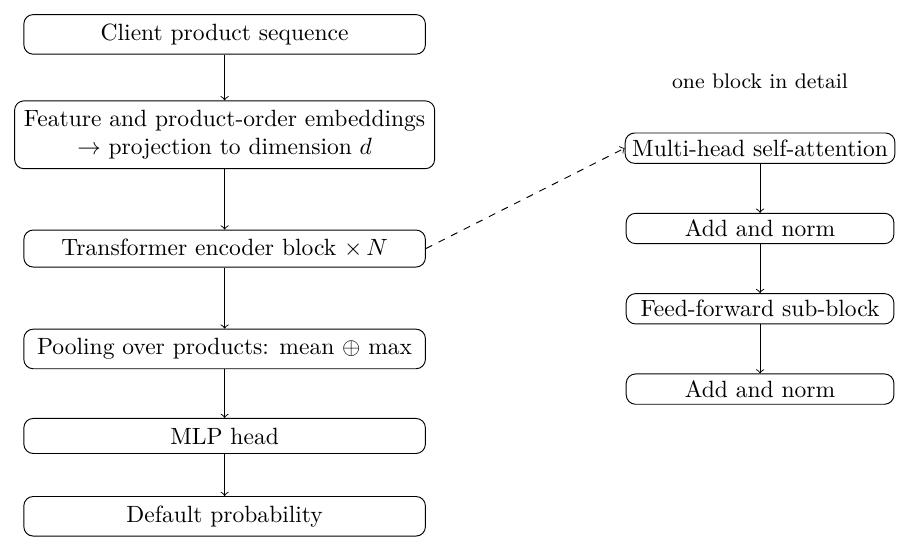

### Иерархический трансформер

Сначала для каждого продукта отдельно обрабатывается его помесячная история платежей, полученные векторы продуктов вместе с остальными признаками подаются в трансформер по последовательности продуктов.

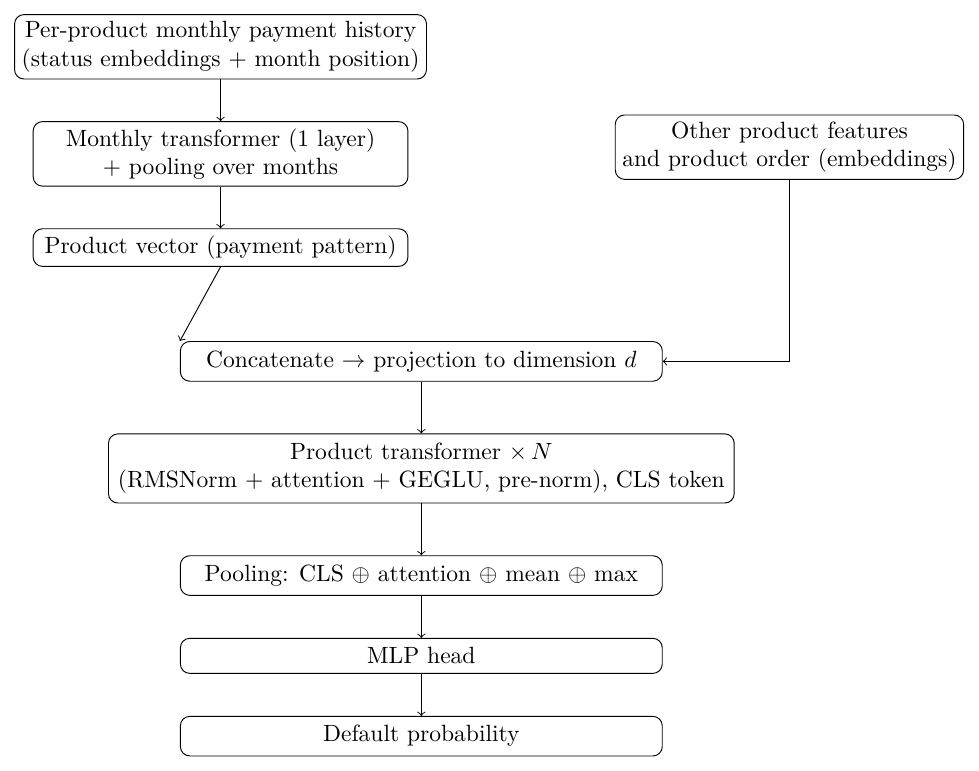

In [27]:
def pick_nhead(d_model, candidates=(8, 6, 4, 2, 1)):
    return max(h for h in candidates if d_model % h == 0)


def masked_mean_max(out, mask):
    weights = mask.unsqueeze(-1).float()
    mean = (out * weights).sum(1) / weights.sum(1).clamp(min=1)
    maximum = out.masked_fill(mask.unsqueeze(-1) == 0, -1e4).max(1).values
    return mean, maximum


class FeatEmbed(nn.Module):
    def __init__(self, vocab_list, emb_dim=16, rn_vocab=64, d_model=256):
        super().__init__()
        offsets = np.cumsum([0] + list(vocab_list[:-1])).astype('int64')
        self.register_buffer('offsets', torch.tensor(offsets))
        self.nf = len(vocab_list)
        self.table = nn.Embedding(int(sum(vocab_list)), emb_dim)
        self.rn_emb = nn.Embedding(rn_vocab, emb_dim)
        self.proj = nn.Sequential(
            nn.Linear(emb_dim * (self.nf + 1), d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

    def forward(self, features, rn):
        x = self.table(features + self.offsets).flatten(2)
        x = torch.cat([x, self.rn_emb(rn)], dim=-1)
        return self.proj(x)

In [28]:
class GRUNet(nn.Module):
    def __init__(self, vocab_list, d_model=256, hidden=256, layers=2, dropout=0.2):
        super().__init__()
        self.emb = FeatEmbed(vocab_list, d_model=d_model)
        self.gru = nn.GRU(
            d_model, hidden, num_layers=layers, batch_first=True,
            bidirectional=True, dropout=dropout if layers > 1 else 0.0,
        )
        out_dim = hidden * 2
        self.head = nn.Sequential(
            nn.Linear(out_dim * 3, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, features, rn, mask):
        x = self.emb(features, rn)
        lengths = mask.sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        mean, maximum = masked_mean_max(out, mask[:, :out.size(1)])
        last_idx = (lengths - 1).to(out.device).long()
        last = out[torch.arange(out.size(0), device=out.device), last_idx]
        return self.head(torch.cat([mean, maximum, last], dim=-1))


class TransformerNet(nn.Module):
    def __init__(self, vocab_list, d_model=256, nhead=8, nlayers=3, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.emb = FeatEmbed(vocab_list, d_model=d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True, activation='gelu',
        )
        self.enc = nn.TransformerEncoder(layer, nlayers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.Linear(d_model * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, features, rn, mask):
        x = self.emb(features, rn)
        out = self.enc(x, src_key_padding_mask=(mask == 0))
        mean, maximum = masked_mean_max(out, mask)
        return self.head(torch.cat([mean, maximum], dim=-1))

In [29]:
class TCNBlock(nn.Module):
    def __init__(self, channels, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel, padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(channels, channels, kernel, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn2 = nn.BatchNorm1d(channels)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        y = self.drop(self.act(self.bn1(self.conv1(x))))
        y = self.drop(self.act(self.bn2(self.conv2(y))))
        return self.act(x + y)


class TCNNet(nn.Module):
    def __init__(self, vocab_list, d_model=256, channels=256, dilations=(1, 2, 4, 8), dropout=0.1):
        super().__init__()
        self.emb = FeatEmbed(vocab_list, d_model=d_model)
        self.inp = nn.Conv1d(d_model, channels, 1)
        self.blocks = nn.ModuleList([TCNBlock(channels, 3, d, dropout) for d in dilations])
        self.head = nn.Sequential(
            nn.Linear(channels * 2, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, features, rn, mask):
        x = self.emb(features, rn) * mask.unsqueeze(-1).float()
        x = self.inp(x.transpose(1, 2))
        for block in self.blocks:
            x = block(x)
        x = x.transpose(1, 2)
        mean, maximum = masked_mean_max(x, mask)
        return self.head(torch.cat([mean, maximum], dim=-1))

In [30]:
class AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q = nn.Parameter(torch.zeros(1, 1, d))
        nn.init.normal_(self.q, std=0.02)
        self.scale = d ** -0.5

    def forward(self, x, mask):
        scores = (x @ self.q.transpose(1, 2)).squeeze(-1) * self.scale
        weights = scores.masked_fill(mask == 0, -1e4).softmax(1).unsqueeze(-1)
        return (x * weights).sum(1)


class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.w = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        scale = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * scale * self.w


class GEGLU(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.w12 = nn.Linear(d, hidden * 2)
        self.w3 = nn.Linear(hidden, d)

    def forward(self, x):
        a, b = self.w12(x).chunk(2, dim=-1)
        return self.w3(torch.nn.functional.gelu(a) * b)


class LlamaBlock(nn.Module):
    def __init__(self, d, nhead, hidden, dropout=0.1):
        super().__init__()
        self.n1 = RMSNorm(d)
        self.attn = nn.MultiheadAttention(d, nhead, dropout=dropout, batch_first=True)
        self.n2 = RMSNorm(d)
        self.ff = GEGLU(d, hidden)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask):
        h = self.n1(x)
        attended, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + self.drop(attended)
        x = x + self.drop(self.ff(self.n2(x)))
        return x


class MonthEncoder(nn.Module):
    def __init__(self, vocab, n_months, emb=12, d_out=48, nhead=4):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb)
        self.pos = nn.Embedding(n_months, emb)
        layer = nn.TransformerEncoderLayer(
            emb, nhead, emb * 2, 0.1, batch_first=True, activation='gelu', norm_first=True,
        )
        self.enc = nn.TransformerEncoder(layer, 1, enable_nested_tensor=False)
        self.proj = nn.Linear(emb * 2, d_out)

    def forward(self, months):
        batch, n_products, n_months = months.shape
        embedded = self.emb(months.reshape(batch * n_products, n_months))
        embedded = embedded + self.pos(torch.arange(n_months, device=months.device))[None]
        encoded = self.enc(embedded)
        pooled = torch.cat([encoded.mean(1), encoded.max(1).values], -1)
        return self.proj(pooled).reshape(batch, n_products, -1)

In [31]:
class TransformerHierNet(nn.Module):
    def __init__(self, vocab_list, seq_cols, d_model=256, nhead=8, nlayers=4,
                 hidden=512, dropout=0.1, max_len=50):
        super().__init__()
        self.paym_idx = [i for i, c in enumerate(seq_cols) if c.startswith('enc_paym_')]
        self.other_idx = [i for i in range(len(seq_cols)) if i not in self.paym_idx]

        other_vocab = [vocab_list[i] for i in self.other_idx]
        offsets = np.cumsum([0] + list(other_vocab[:-1])).astype('int64')
        self.register_buffer('off', torch.tensor(offsets))
        self.emb_other = nn.Embedding(int(sum(other_vocab)), 16)

        paym_vocab = max(vocab_list[i] for i in self.paym_idx) if self.paym_idx else 2
        self.month = MonthEncoder(int(paym_vocab), max(1, len(self.paym_idx)), emb=12, d_out=48)
        self.rn = nn.Embedding(64, 16)

        in_dim = 16 * len(self.other_idx) + 48 + 16
        self.proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList(
            [LlamaBlock(d_model, nhead, hidden, dropout) for _ in range(nlayers)])
        self.norm = RMSNorm(d_model)
        self.attn = AttnPool(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model * 4, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, features, rn, mask):
        batch = features.size(0)
        other = self.emb_other(features[:, :, self.other_idx] + self.off).flatten(2)
        months = self.month(features[:, :, self.paym_idx])
        tokens = self.proj(torch.cat([other, months, self.rn(rn)], dim=-1))

        tokens = torch.cat([self.cls.expand(batch, -1, -1), tokens], 1)
        full_mask = torch.cat([torch.ones(batch, 1, dtype=torch.bool, device=mask.device), mask], 1)
        for block in self.blocks:
            tokens = block(tokens, full_mask == 0)

        tokens = self.norm(tokens)
        cls_out = tokens[:, 0]
        seq = tokens[:, 1:]
        mean, maximum = masked_mean_max(seq, mask)
        return self.head(torch.cat([cls_out, self.attn(seq, mask), mean, maximum], dim=-1))

## Модели

Модели с одним интерфейсом обучения и предсказания. Для нейросетей предусмотрены ранняя остановка и аккуратное дообучение.

In [32]:
from xgboost import XGBClassifier


class XGBModel(BaseModel):
    name = 'xgboost'
    DEFAULTS = dict(
        learning_rate=0.02, max_depth=7, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, gamma=0.0,
    )

    def _params(self):
        params = dict(self.params)
        pos = max(float((y == 1).sum()), 1.0)
        params.setdefault('scale_pos_weight', float((y == 0).sum()) / pos)
        params.update(
            n_estimators=6000, max_bin=256, eval_metric='auc',
            early_stopping_rounds=200, random_state=SEED, n_jobs=-1,
            tree_method='gpu_hist',
        )
        return params

    def fit_fold(self, train_idx, val_idx):
        self.model = XGBClassifier(**self._params())
        self.model.fit(
            X_agg_np[train_idx], y[train_idx],
            eval_set=[(X_agg_np[val_idx], y[val_idx])], verbose=False,
        )

    def _ckpt_exists(self, path):
        return os.path.exists(path + '.json')

    def predict(self, idx, which):
        matrix = X_test_agg_np if which == 'test' else X_agg_np[idx]
        return self.model.predict_proba(matrix)[:, 1]

    def save(self, path):
        self.model.save_model(path + '.json')

    def load(self, path):
        self.model = XGBClassifier()
        self.model.load_model(path + '.json')

    def finetune(self, train_idx, val_idx):
        booster = self.model.get_booster()
        self.model = XGBClassifier(**self._params())
        self.model.fit(
            X_agg_np[train_idx], y[train_idx],
            eval_set=[(X_agg_np[val_idx], y[val_idx])], verbose=False, xgb_model=booster,
        )

In [33]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.step = 0
        self.shadow = {k: v.detach().clone().float() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        self.step += 1
        decay = min(self.decay, (1.0 + self.step) / (10.0 + self.step))
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(decay).add_(v.detach().float(), alpha=1 - decay)
            else:
                self.shadow[k].copy_(v)

    @torch.no_grad()
    def copy_to(self, model):
        for k, v in model.state_dict().items():
            v.copy_(self.shadow[k].to(v.dtype))


class SeqModel(BaseModel):
    DEFAULTS = dict(d_model=None, gru_layers=None, tf_layers=None, tf_ff=None,
                    max_lr=None, weight_decay=1e-5)

    def __init__(self, params=None):
        super().__init__(params)
        self.epochs = MODEL_EPOCHS.get(self.name, 20)
        self.n_seeds = N_SEEDS
        self.init_state = None
        self.bs = None
        self._K = 1
        self._k = 1
        self._ep_times = []
        self._ep_count = 0

    def build_net(self):
        raise NotImplementedError

    def _slice(self, features, rn, lengths, idx):
        f = features[idx].long()
        r = rn[idx].long()
        length = lengths[idx].long()
        mask = torch.arange(f.shape[1], device=DEVICE)[None, :] < length[:, None]
        return f, r, mask

    @torch.no_grad()
    def _infer_net(self, net, features, rn, lengths, idx):
        net.eval()
        batch_size = self.bs or BATCH
        chunks = []
        for i in range(0, len(idx), batch_size):
            f, r, mask = self._slice(features, rn, lengths, idx[i:i + batch_size])
            with torch.autocast('cuda', dtype=AMP_DTYPE):
                prob = torch.sigmoid(net(f, r, mask).squeeze(1))
            chunks.append(prob.float().cpu().numpy())
        return np.concatenate(chunks)

    def _infer(self, features, rn, lengths, idx):
        per_net = [self._infer_net(net, features, rn, lengths, idx) for net in self.nets]
        return np.mean(per_net, axis=0)

    def _make_scheduler(self, optimizer, steps_per_epoch, lr_max):
        if self.init_state is not None:
            return torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=steps_per_epoch * self.epochs, eta_min=lr_max * 0.02)
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr_max, steps_per_epoch=steps_per_epoch, epochs=self.epochs)

    def _run_epoch(self, net, optimizer, scheduler, ema, loss_fn,
                   train_idx, label_smooth, grad_clip):
        net.train()
        order = train_idx[torch.randperm(len(train_idx), device=DEVICE)]
        for i in range(0, len(order), self.bs):
            batch = order[i:i + self.bs]
            f, r, mask = self._slice(TR_F, TR_R, TR_L, batch)
            labels = TR_Yg[batch]
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + 0.5 * label_smooth

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast('cuda', dtype=AMP_DTYPE):
                loss = loss_fn(net(f, r, mask).squeeze(1), labels)
            loss.backward()
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(net.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            self._gstep += 1
            if self._gstep % EMA_EVERY == 0:
                ema.update(net)

    def _evaluate(self, net, ema, ema_net, val_idx, val_labels):
        auc_raw = roc_auc_score(val_labels, self._infer_net(net, TR_F, TR_R, TR_L, val_idx))
        ema.copy_to(ema_net)
        auc_ema = roc_auc_score(val_labels, self._infer_net(ema_net, TR_F, TR_R, TR_L, val_idx))
        if auc_ema >= auc_raw:
            return auc_ema, ema_net, auc_raw, auc_ema
        return auc_raw, net, auc_raw, auc_ema

    def _train_one(self, train_idx, val_idx, seed):
        torch.manual_seed(SEED + seed)
        net = self.build_net().to(DEVICE)
        if self.init_state is not None:
            net.load_state_dict(self.init_state)
        ema = EMA(net, EMA_DECAY)
        ema_net = self.build_net().to(DEVICE)

        train_t = torch.as_tensor(train_idx, device=DEVICE)
        val_eval = val_idx if len(val_idx) <= VAL_SUBSAMPLE else val_idx[:VAL_SUBSAMPLE]
        val_eval_t = torch.as_tensor(val_eval, device=DEVICE)
        val_labels = TR_Y[val_eval]

        pos = max(float(TR_Y[train_idx].sum()), 1.0)
        neg = float((TR_Y[train_idx] == 0).sum())
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(neg / pos, device=DEVICE))

        lr_max = self.params.get('max_lr') or MAX_LR
        weight_decay = self.params.get('weight_decay') or 1e-5
        optimizer = torch.optim.AdamW(net.parameters(), lr=lr_max, weight_decay=weight_decay)
        grad_clip = self.params.get('grad_clip')
        label_smooth = self.params.get('label_smooth') or 0.0
        steps_per_epoch = max(1, (len(train_t) + self.bs - 1) // self.bs)
        scheduler = self._make_scheduler(optimizer, steps_per_epoch, lr_max)

        best_auc = 0.0
        best_state = None
        patience = 0
        self._gstep = 0

        for epoch in range(self.epochs):
            epoch_start = time.time()
            self._run_epoch(net, optimizer, scheduler, ema, loss_fn,
                            train_t, label_smooth, grad_clip)
            auc, source, auc_raw, auc_ema = self._evaluate(
                net, ema, ema_net, val_eval_t, val_labels)
            self._log_epoch(seed, epoch, auc, auc_raw, auc_ema, time.time() - epoch_start)

            if auc > best_auc:
                best_auc = auc
                best_state = {k: v.detach().cpu().clone() for k, v in source.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= PATIENCE:
                    break

        final = self.build_net().to(DEVICE)
        final.load_state_dict(best_state)
        return final, best_auc

    def _log_epoch(self, seed, epoch, auc, auc_raw, auc_ema, seconds):
        self._ep_times.append(seconds)
        self._ep_count += 1
        avg = sum(self._ep_times) / len(self._ep_times)
        planned = self._K * self.n_seeds * self.epochs
        eta = max(0, planned - self._ep_count) * avg
        print(f'  {self.name} фолд {self._k}/{self._K} сид {seed + 1}/{self.n_seeds} '
              f'эпоха {epoch + 1}/{self.epochs} | val={auc:.4f} '
              f'(raw {auc_raw:.4f} / ema {auc_ema:.4f}) | {seconds:.0f}s | ~{eta / 60:.1f} мин')

    def fit_fold(self, train_idx, val_idx):
        self.nets = []
        self.bs = BATCH
        for seed in range(self.n_seeds):
            net, _ = self._train_one(train_idx, val_idx, seed)
            self.nets.append(net)

    def finetune(self, train_idx, val_idx):
        loaded = self.nets
        self.nets = []
        self.bs = BATCH
        base_lr = self.params.get('max_lr')
        self.params['max_lr'] = (base_lr or MAX_LR) / 5.0
        for seed, net in enumerate(loaded):
            self.init_state = net.state_dict()
            tuned, _ = self._train_one(train_idx, val_idx, seed)
            self.nets.append(tuned)
        self.init_state = None
        self.params['max_lr'] = base_lr

    def _ckpt_exists(self, path):
        return len(glob.glob(f'{path}_seed*.pt')) > 0

    def predict(self, idx, which):
        if which == 'test':
            test_idx = torch.arange(Fte.shape[0], device=DEVICE)
            return self._infer(Fte, Rte, Lte, test_idx)
        return self._infer(TR_F, TR_R, TR_L, torch.as_tensor(idx, device=DEVICE))

    def save(self, path):
        for i, net in enumerate(self.nets):
            torch.save(net.state_dict(), f'{path}_seed{i}.pt')

    def load(self, path):
        self.nets = []
        self.bs = BATCH
        for file in sorted(glob.glob(f'{path}_seed*.pt'))[:self.n_seeds]:
            net = self.build_net().to(DEVICE)
            net.load_state_dict(torch.load(file, map_location=DEVICE))
            self.nets.append(net)

In [34]:
class GRUModel(SeqModel):
    name = 'gru'

    def build_net(self):
        d = self.params.get('d_model') or D_MODEL
        layers = self.params.get('gru_layers') or GRU_LAYERS
        dropout = self.params.get('dropout', 0.2)
        return GRUNet([VOCAB[c] for c in SEQ_COLS], d, d, layers, dropout)


class TransformerModel(SeqModel):
    name = 'transformer'

    def build_net(self):
        d = self.params.get('d_model') or D_MODEL
        layers = self.params.get('tf_layers') or TF_LAYERS
        ff = self.params.get('tf_ff') or TF_FF
        dropout = self.params.get('dropout', 0.1)
        return TransformerNet([VOCAB[c] for c in SEQ_COLS], d, pick_nhead(d), layers, ff, dropout)


class TCNModel(SeqModel):
    name = 'cnn'

    def build_net(self):
        d = self.params.get('d_model') or D_MODEL
        levels = self.params.get('tcn_levels') or 4
        dropout = self.params.get('dropout', 0.1)
        dilations = tuple(2 ** i for i in range(levels))
        return TCNNet([VOCAB[c] for c in SEQ_COLS], d, d, dilations, dropout)

In [35]:
class TransformerHierModel(SeqModel):
    name = 'transformer_hier'

    def __init__(self, params=None):
        defaults = dict(d_model=256, max_lr=1.2e-3, weight_decay=0.02,
                        grad_clip=1.0, label_smooth=0.02)
        if params:
            defaults.update(params)
        super().__init__(defaults)

    def build_net(self):
        d = self.params.get('d_model') or 256
        nhead = pick_nhead(d, (8, 4, 2, 1))
        nlayers = self.params.get('hier_layers') or 4
        hidden = d * (self.params.get('hier_hidden_mult') or 2)
        dropout = self.params.get('dropout', 0.1)
        vocab = [VOCAB[c] for c in SEQ_COLS]
        return TransformerHierNet(vocab, SEQ_COLS, d, nhead, nlayers, hidden, dropout, MAX_LEN)

## Обучение по фолдам

Вспомогательная процедура, которая обучает модель по фолдам и сохраняет её предсказания для дальнейшего объединения.

In [36]:
def make_folds(n_splits):
    splitter = StratifiedKFold(n_splits, shuffle=True, random_state=SEED)
    return list(splitter.split(np.zeros(len(y)), y))

folds_gbdt = make_folds(GBDT_FOLDS)
folds_nn = make_folds(NN_FOLDS)

SAVE_TO = SAVE_DIR if SAVE_MODELS else None
PRED_DIR = os.path.join(SAVE_DIR, 'preds')
os.makedirs(PRED_DIR, exist_ok=True)

MODELS = ['xgboost', 'gru', 'transformer', 'cnn', 'transformer_hier']
runs = globals().get('runs', {})


def save_preds(name, result):
    np.savez(os.path.join(PRED_DIR, f'{name}.npz'),
             oof=result['oof'], test=result['test'], auc=result['auc'])


def load_saved_preds(names):
    for name in names:
        path = os.path.join(PRED_DIR, f'{name}.npz')
        if name not in runs and os.path.exists(path):
            data = np.load(path)
            runs[name] = {'oof': data['oof'], 'test': data['test'], 'auc': float(data['auc'])}


def run_model(name, model_class, folds):
    result = model_class(MODEL_PARAMS.get(name)).cross_validate(
        y, folds, n_test, SAVE_TO, RESUME, FINETUNE)
    runs[name] = result
    save_preds(name, result)
    print(f'>> {name}: OOF AUC={result["auc"]:.5f} | сохранено в preds/{name}.npz')
    return result

## Обучение моделей

Модели обучаются по отдельности и могут считаться независимо, в том числе в разных сессиях. Повторный проход переиспользует ранее посчитанные результаты.

In [20]:
run_model('xgboost', XGBModel, folds_gbdt)

  [xgboost] фолд 1/5: обучаю с нуля
  [xgboost] фолд 1/5  AUC=0.7603  (67s)
  [xgboost] фолд 2/5: обучаю с нуля
  [xgboost] фолд 2/5  AUC=0.7646  (70s)
  [xgboost] фолд 3/5: обучаю с нуля
  [xgboost] фолд 3/5  AUC=0.7548  (64s)
  [xgboost] фолд 4/5: обучаю с нуля
  [xgboost] фолд 4/5  AUC=0.7576  (71s)
  [xgboost] фолд 5/5: обучаю с нуля
  [xgboost] фолд 5/5  AUC=0.7575  (69s)
== xgboost: OOF AUC = 0.7590  (фолды 0.7590 +/- 0.0033) | 5.7 мин
>> xgboost: OOF AUC=0.75896 | сохранено в preds/xgboost.npz


{'name': 'xgboost',
 'oof': array([0.21863207, 0.42730415, 0.53102082, ..., 0.36654511, 0.73273522,
        0.41124442]),
 'test': array([0.42944324, 0.52635193, 0.34031773, ..., 0.68964648, 0.16142385,
        0.35092981]),
 'auc': 0.7589624208908733}

In [21]:
run_model('gru', GRUModel, folds_nn)

  [gru] фолд 1/5: обучаю с нуля
  gru фолд 1/5 сид 1/1 эпоха 1/10 | val=0.7700 (raw 0.7614 / ema 0.7700) | 21s | ~17.0 мин
  gru фолд 1/5 сид 1/1 эпоха 2/10 | val=0.7758 (raw 0.7728 / ema 0.7758) | 20s | ~16.2 мин
  gru фолд 1/5 сид 1/1 эпоха 3/10 | val=0.7812 (raw 0.7742 / ema 0.7812) | 20s | ~15.7 мин
  gru фолд 1/5 сид 1/1 эпоха 4/10 | val=0.7846 (raw 0.7846 / ema 0.7829) | 20s | ~15.3 мин
  gru фолд 1/5 сид 1/1 эпоха 5/10 | val=0.7842 (raw 0.7833 / ema 0.7842) | 20s | ~14.9 мин
  gru фолд 1/5 сид 1/1 эпоха 6/10 | val=0.7855 (raw 0.7855 / ema 0.7848) | 20s | ~14.6 мин
  gru фолд 1/5 сид 1/1 эпоха 7/10 | val=0.7865 (raw 0.7864 / ema 0.7865) | 20s | ~14.2 мин
  gru фолд 1/5 сид 1/1 эпоха 8/10 | val=0.7873 (raw 0.7869 / ema 0.7873) | 20s | ~13.9 мин
  gru фолд 1/5 сид 1/1 эпоха 9/10 | val=0.7877 (raw 0.7876 / ema 0.7877) | 20s | ~13.5 мин
  gru фолд 1/5 сид 1/1 эпоха 10/10 | val=0.7878 (raw 0.7877 / ema 0.7878) | 20s | ~13.2 мин
  [gru] фолд 1/5  AUC=0.7821  (202s)
  [gru] фолд 2/5: об

{'name': 'gru',
 'oof': array([0.16796875, 0.69140625, 0.77734375, ..., 0.19921875, 0.8046875 ,
        0.7734375 ]),
 'test': array([0.46171875, 0.41484375, 0.36992187, ..., 0.80390625, 0.11464844,
        0.36992187]),
 'auc': 0.7815606018445931}

In [22]:
run_model('transformer', TransformerModel, folds_nn)

  [transformer] фолд 1/5: обучаю с нуля
  transformer фолд 1/5 сид 1/1 эпоха 1/15 | val=0.7666 (raw 0.7666 / ema 0.7659) | 29s | ~36.2 мин
  transformer фолд 1/5 сид 1/1 эпоха 2/15 | val=0.7763 (raw 0.7719 / ema 0.7763) | 29s | ~35.6 мин
  transformer фолд 1/5 сид 1/1 эпоха 3/15 | val=0.7800 (raw 0.7769 / ema 0.7800) | 29s | ~35.1 мин
  transformer фолд 1/5 сид 1/1 эпоха 4/15 | val=0.7832 (raw 0.7787 / ema 0.7832) | 29s | ~34.6 мин
  transformer фолд 1/5 сид 1/1 эпоха 5/15 | val=0.7855 (raw 0.7855 / ema 0.7850) | 29s | ~34.1 мин
  transformer фолд 1/5 сид 1/1 эпоха 6/15 | val=0.7865 (raw 0.7760 / ema 0.7865) | 29s | ~33.6 мин
  transformer фолд 1/5 сид 1/1 эпоха 7/15 | val=0.7869 (raw 0.7855 / ema 0.7869) | 29s | ~33.2 мин
  transformer фолд 1/5 сид 1/1 эпоха 8/15 | val=0.7877 (raw 0.7861 / ema 0.7877) | 29s | ~32.7 мин
  transformer фолд 1/5 сид 1/1 эпоха 9/15 | val=0.7882 (raw 0.7873 / ema 0.7882) | 29s | ~32.2 мин
  transformer фолд 1/5 сид 1/1 эпоха 10/15 | val=0.7881 (raw 0.7861 /

{'name': 'transformer',
 'oof': array([0.16210938, 0.7890625 , 0.83203125, ..., 0.19042969, 0.828125  ,
        0.83203125]),
 'test': array([0.40351563, 0.46289062, 0.28027344, ..., 0.78124999, 0.10625   ,
        0.30234375]),
 'auc': 0.7828135939722323}

In [23]:
run_model('cnn', TCNModel, folds_nn)

  [cnn] фолд 1/5: обучаю с нуля
  cnn фолд 1/5 сид 1/1 эпоха 1/18 | val=0.7639 (raw 0.7623 / ema 0.7639) | 22s | ~32.8 мин
  cnn фолд 1/5 сид 1/1 эпоха 2/18 | val=0.7759 (raw 0.7696 / ema 0.7759) | 20s | ~30.8 мин
  cnn фолд 1/5 сид 1/1 эпоха 3/18 | val=0.7810 (raw 0.7774 / ema 0.7810) | 20s | ~29.9 мин
  cnn фолд 1/5 сид 1/1 эпоха 4/18 | val=0.7839 (raw 0.7579 / ema 0.7839) | 20s | ~29.3 мин
  cnn фолд 1/5 сид 1/1 эпоха 5/18 | val=0.7859 (raw 0.7859 / ema 0.7851) | 20s | ~28.8 мин
  cnn фолд 1/5 сид 1/1 эпоха 6/18 | val=0.7865 (raw 0.7784 / ema 0.7865) | 20s | ~28.4 мин
  cnn фолд 1/5 сид 1/1 эпоха 7/18 | val=0.7874 (raw 0.7839 / ema 0.7874) | 20s | ~27.9 мин
  cnn фолд 1/5 сид 1/1 эпоха 8/18 | val=0.7884 (raw 0.7847 / ema 0.7884) | 20s | ~27.6 мин
  cnn фолд 1/5 сид 1/1 эпоха 9/18 | val=0.7891 (raw 0.7867 / ema 0.7891) | 20s | ~27.2 мин
  cnn фолд 1/5 сид 1/1 эпоха 10/18 | val=0.7893 (raw 0.7870 / ema 0.7893) | 20s | ~26.8 мин
  cnn фолд 1/5 сид 1/1 эпоха 11/18 | val=0.7896 (raw 0.78

{'name': 'cnn',
 'oof': array([0.12597656, 0.7109375 , 0.7890625 , ..., 0.13574219, 0.81640625,
        0.6640625 ]),
 'test': array([0.41757812, 0.40468751, 0.3265625 , ..., 0.74453124, 0.10214844,
        0.32265625]),
 'auc': 0.7836197169336833}

In [37]:
run_model('transformer_hier', TransformerHierModel, folds_nn)

  [transformer_hier] фолд 1/5: загружен из models/
  [transformer_hier] фолд 1/5  AUC=0.7860  (34s)
  [transformer_hier] фолд 2/5: загружен из models/
  [transformer_hier] фолд 2/5  AUC=0.7897  (34s)
  [transformer_hier] фолд 3/5: загружен из models/
  [transformer_hier] фолд 3/5  AUC=0.7833  (34s)
  [transformer_hier] фолд 4/5: обучаю с нуля
  transformer_hier фолд 4/5 сид 1/1 эпоха 1/8 | val=0.7749 (raw 0.7734 / ema 0.7749) | 181s | ~117.5 мин
  transformer_hier фолд 4/5 сид 1/1 эпоха 2/8 | val=0.7810 (raw 0.7567 / ema 0.7810) | 181s | ~114.5 мин
  transformer_hier фолд 4/5 сид 1/1 эпоха 3/8 | val=0.7853 (raw 0.7761 / ema 0.7853) | 181s | ~111.5 мин
  transformer_hier фолд 4/5 сид 1/1 эпоха 4/8 | val=0.7882 (raw 0.7600 / ema 0.7882) | 181s | ~108.5 мин
  transformer_hier фолд 4/5 сид 1/1 эпоха 5/8 | val=0.7901 (raw 0.7794 / ema 0.7901) | 181s | ~105.5 мин
  transformer_hier фолд 4/5 сид 1/1 эпоха 6/8 | val=0.7911 (raw 0.7906 / ema 0.7911) | 181s | ~102.4 мин
  transformer_hier фолд 4

{'name': 'transformer_hier',
 'oof': array([0.44921875, 0.7734375 , 0.8515625 , ..., 0.4375    , 0.84375   ,
        0.828125  ]),
 'test': array([0.58125001, 0.57734375, 0.52109374, ..., 0.83515626, 0.415625  ,
        0.5421875 ]),
 'auc': 0.7847761254480549}

## Самостоятельная разметка теста

Наиболее уверенные предсказания на тестовых данных используются как дополнительные обучающие примеры, после чего каждая модель дообучается. Сначала выполняется подготовка, затемьдообучение моделей.

In [38]:
from scipy.stats import rankdata

load_saved_preds(MODELS)
base_names = [n for n in MODELS if n in runs]
print('базовые модели для псевдо-меток:', base_names)

test_rank = np.mean([rankdata(runs[n]['test']) / len(runs[n]['test']) for n in base_names], axis=0)
positive_idx = np.where(test_rank >= PL_POS_Q)[0]
negative_pool = np.where((test_rank <= PL_NEG_Q) & (test_rank < PL_POS_Q))[0]

rng = np.random.RandomState(SEED)
n_negative = min(len(negative_pool), max(1, len(positive_idx)) * PL_MAX_NEG_MULT)
if len(negative_pool):
    negative_idx = rng.choice(negative_pool, n_negative, replace=False)
else:
    negative_idx = negative_pool

confident_idx = np.concatenate([positive_idx, negative_idx]).astype(np.int64)
pseudo_labels = np.concatenate(
    [np.ones(len(positive_idx)), np.zeros(len(negative_idx))]).astype(np.int8)
print(f'псевдо-метки: +{len(positive_idx)} / -{len(negative_idx)} из {len(test_rank)} тестовых')

confident_t = torch.as_tensor(confident_idx, device=DEVICE)
F_combined = torch.cat([Ftr, Fte[confident_t]])
R_combined = torch.cat([Rtr, Rte[confident_t]])
L_combined = torch.cat([Ltr, Lte[confident_t]])
labels_combined = np.concatenate([y, pseudo_labels]).astype(np.int8)
labels_combined_gpu = torch.as_tensor(labels_combined, dtype=torch.float32, device=DEVICE)

N_TRAIN = len(y)
pseudo_extra = np.arange(N_TRAIN, N_TRAIN + len(confident_idx))
pl_folds = [(np.concatenate([train_idx, pseudo_extra]), val_idx) for train_idx, val_idx in folds_nn]

базовые модели для псевдо-меток: ['xgboost', 'gru', 'transformer', 'cnn', 'transformer_hier']
псевдо-метки: +80927 / -404635 из 900000 тестовых


In [39]:
def run_pl(base, model_class):
    name = f'{base}_pl'
    if not FINETUNE and os.path.exists(os.path.join(PRED_DIR, f'{name}.npz')):
        load_saved_preds([name])
        print(f'{name}: уже посчитано -> пропускаю')
        return
    if not glob.glob(os.path.join(SAVE_DIR, f'{base}_fold0_seed*.pt')):
        print(f'нет весов {base} -> сначала обучи базовую модель')
        return

    global TR_F, TR_R, TR_L, TR_Yg, TR_Y
    TR_F, TR_R, TR_L, TR_Yg, TR_Y = (
        F_combined, R_combined, L_combined, labels_combined_gpu, labels_combined)

    model = model_class(MODEL_PARAMS.get(base))
    model.name = name
    model.epochs = PL_EPOCHS
    oof = np.zeros(N_TRAIN)
    test = np.zeros(n_test)

    model._K = len(pl_folds)
    model._ep_times = []
    model._ep_count = 0
    for k, (train_idx, val_idx) in enumerate(pl_folds):
        pl_files = sorted(glob.glob(os.path.join(SAVE_DIR, f'{name}_fold{k}_seed*.pt')))[:N_SEEDS]
        base_files = sorted(glob.glob(os.path.join(SAVE_DIR, f'{base}_fold{k}_seed*.pt')))[:N_SEEDS]
        seed_files = pl_files if pl_files else base_files
        source = 'продолжаю _pl' if pl_files else 'старт от базы'
        print(f'  [{name}] фолд {k + 1}/{len(pl_folds)}: {source}, дообучаю {PL_EPOCHS} эп')
        model.nets = []
        model.bs = BATCH
        model.n_seeds = len(seed_files)
        model._k = k + 1
        for seed, file in enumerate(seed_files):
            model.init_state = torch.load(file, map_location=DEVICE)
            net, _ = model._train_one(train_idx, val_idx, seed)
            model.nets.append(net)
        model.init_state = None
        model.save(os.path.join(SAVE_DIR, f'{name}_fold{k}'))
        oof[val_idx] = model.predict(val_idx, 'train')
        test += model.predict(None, 'test') / len(pl_folds)

    TR_F, TR_R, TR_L, TR_Yg, TR_Y = Ftr, Rtr, Ltr, y_gpu, y
    auc = roc_auc_score(y, oof)
    runs[name] = {'oof': oof, 'test': test, 'auc': float(auc)}
    save_preds(name, runs[name])
    base_part = f' (база {runs[base]["auc"]:.5f})' if base in runs else ''
    print(f'>> {name}: OOF AUC={auc:.5f}{base_part}')

In [40]:
def run_pl_gbdt(base, model_class):
    name = f'{base}_pl'
    if not FINETUNE and os.path.exists(os.path.join(PRED_DIR, f'{name}.npz')):
        load_saved_preds([name])
        print(f'{name}: уже посчитано -> пропускаю')
        return

    X_combined = np.vstack([X_agg_np, X_test_agg_np[confident_idx]])
    labels = np.concatenate([y, pseudo_labels]).astype(np.int8)
    oof = np.zeros(N_TRAIN)
    test = np.zeros(n_test)
    gbdt_start = time.time()

    for k, (train_idx, val_idx) in enumerate(folds_gbdt):
        full_train = np.concatenate([train_idx, np.arange(N_TRAIN, len(labels))])
        pl_path = os.path.join(SAVE_DIR, f'{name}_fold{k}.json')
        base_path = os.path.join(SAVE_DIR, f'{base}_fold{k}.json')
        if os.path.exists(pl_path):
            warm_path = pl_path
            source = 'продолжаю _pl'
        elif os.path.exists(base_path):
            warm_path = base_path
            source = 'старт от базы'
        else:
            warm_path = None
            source = 'с нуля'
        print(f'  [{name}] фолд {k + 1}/{len(folds_gbdt)}: {source}, дообучаю XGBoost')
        booster = None
        if warm_path:
            prior = XGBClassifier()
            prior.load_model(warm_path)
            booster = prior.get_booster()
        model = XGBClassifier(**model_class(MODEL_PARAMS.get(base))._params())
        model.fit(X_combined[full_train], labels[full_train],
                  eval_set=[(X_agg_np[val_idx], y[val_idx])], verbose=200, xgb_model=booster)
        model.save_model(pl_path)
        oof[val_idx] = model.predict_proba(X_agg_np[val_idx])[:, 1]
        test += model.predict_proba(X_test_agg_np)[:, 1] / len(folds_gbdt)
        fold_auc = roc_auc_score(y[val_idx], oof[val_idx])
        eta = (time.time() - gbdt_start) / (k + 1) * (len(folds_gbdt) - k - 1)
        print(f'  [{name}] фолд {k + 1}/{len(folds_gbdt)}: '
              f'AUC={fold_auc:.4f} | ~{eta / 60:.1f} мин')

    auc = roc_auc_score(y, oof)
    runs[name] = {'oof': oof, 'test': test, 'auc': float(auc)}
    save_preds(name, runs[name])
    base_part = f' (база {runs[base]["auc"]:.5f})' if base in runs else ''
    print(f'>> {name}: OOF AUC={auc:.5f}{base_part}')

In [41]:
run_pl_gbdt('xgboost', XGBModel)

  [xgboost_pl] фолд 1/5: старт от базы, дообучаю XGBoost
[0]	validation_0-auc:0.76029
[200]	validation_0-auc:0.75906
[203]	validation_0-auc:0.75908
  [xgboost_pl] фолд 1/5: AUC=0.7603 | ~2.1 мин
  [xgboost_pl] фолд 2/5: старт от базы, дообучаю XGBoost
[0]	validation_0-auc:0.76462
[200]	validation_0-auc:0.76322
[201]	validation_0-auc:0.76321
  [xgboost_pl] фолд 2/5: AUC=0.7646 | ~1.6 мин
  [xgboost_pl] фолд 3/5: старт от базы, дообучаю XGBoost
[0]	validation_0-auc:0.75475
[200]	validation_0-auc:0.75362
[202]	validation_0-auc:0.75364
  [xgboost_pl] фолд 3/5: AUC=0.7548 | ~1.1 мин
  [xgboost_pl] фолд 4/5: старт от базы, дообучаю XGBoost
[0]	validation_0-auc:0.75761
[200]	validation_0-auc:0.75637
[204]	validation_0-auc:0.75641
  [xgboost_pl] фолд 4/5: AUC=0.7577 | ~0.5 мин
  [xgboost_pl] фолд 5/5: старт от базы, дообучаю XGBoost
[0]	validation_0-auc:0.75750
[200]	validation_0-auc:0.75675
[209]	validation_0-auc:0.75681
  [xgboost_pl] фолд 5/5: AUC=0.7575 | ~0.0 мин
>> xgboost_pl: OOF AUC=0.

In [42]:
run_pl('gru', GRUModel)

  [gru_pl] фолд 1/5: старт от базы, дообучаю 4 эп
  gru_pl фолд 1/5 сид 1/1 эпоха 1/4 | val=0.7887 (raw 0.7880 / ema 0.7887) | 25s | ~8.1 мин
  gru_pl фолд 1/5 сид 1/1 эпоха 2/4 | val=0.7898 (raw 0.7893 / ema 0.7898) | 25s | ~7.6 мин
  gru_pl фолд 1/5 сид 1/1 эпоха 3/4 | val=0.7907 (raw 0.7907 / ema 0.7903) | 25s | ~7.2 мин
  gru_pl фолд 1/5 сид 1/1 эпоха 4/4 | val=0.7905 (raw 0.7905 / ema 0.7904) | 25s | ~6.7 мин
  [gru_pl] фолд 2/5: старт от базы, дообучаю 4 эп
  gru_pl фолд 2/5 сид 1/1 эпоха 1/4 | val=0.7987 (raw 0.7985 / ema 0.7987) | 25s | ~6.3 мин
  gru_pl фолд 2/5 сид 1/1 эпоха 2/4 | val=0.7997 (raw 0.7986 / ema 0.7997) | 25s | ~5.9 мин
  gru_pl фолд 2/5 сид 1/1 эпоха 3/4 | val=0.8003 (raw 0.7997 / ema 0.8003) | 25s | ~5.5 мин
  gru_pl фолд 2/5 сид 1/1 эпоха 4/4 | val=0.8007 (raw 0.8007 / ema 0.8005) | 25s | ~5.1 мин
  [gru_pl] фолд 3/5: старт от базы, дообучаю 4 эп
  gru_pl фолд 3/5 сид 1/1 эпоха 1/4 | val=0.7925 (raw 0.7913 / ema 0.7925) | 26s | ~4.6 мин
  gru_pl фолд 3/5 сид 

In [43]:
run_pl('transformer', TransformerModel)

  [transformer_pl] фолд 1/5: старт от базы, дообучаю 4 эп
  transformer_pl фолд 1/5 сид 1/1 эпоха 1/4 | val=0.7899 (raw 0.7891 / ema 0.7899) | 37s | ~11.8 мин
  transformer_pl фолд 1/5 сид 1/1 эпоха 2/4 | val=0.7911 (raw 0.7894 / ema 0.7911) | 37s | ~11.2 мин
  transformer_pl фолд 1/5 сид 1/1 эпоха 3/4 | val=0.7907 (raw 0.7903 / ema 0.7907) | 37s | ~10.6 мин
  transformer_pl фолд 1/5 сид 1/1 эпоха 4/4 | val=0.7907 (raw 0.7906 / ema 0.7907) | 37s | ~10.0 мин
  [transformer_pl] фолд 2/5: старт от базы, дообучаю 4 эп
  transformer_pl фолд 2/5 сид 1/1 эпоха 1/4 | val=0.7998 (raw 0.7998 / ema 0.7991) | 37s | ~9.3 мин
  transformer_pl фолд 2/5 сид 1/1 эпоха 2/4 | val=0.7991 (raw 0.7991 / ema 0.7990) | 37s | ~8.7 мин
  transformer_pl фолд 2/5 сид 1/1 эпоха 3/4 | val=0.7991 (raw 0.7989 / ema 0.7991) | 37s | ~8.1 мин
  transformer_pl фолд 2/5 сид 1/1 эпоха 4/4 | val=0.7986 (raw 0.7986 / ema 0.7986) | 37s | ~7.5 мин
  [transformer_pl] фолд 3/5: старт от базы, дообучаю 4 эп
  transformer_pl фолд 

In [44]:
run_pl('cnn', TCNModel)

  [cnn_pl] фолд 1/5: старт от базы, дообучаю 4 эп
  cnn_pl фолд 1/5 сид 1/1 эпоха 1/4 | val=0.7915 (raw 0.7898 / ema 0.7915) | 26s | ~8.1 мин
  cnn_pl фолд 1/5 сид 1/1 эпоха 2/4 | val=0.7920 (raw 0.7909 / ema 0.7920) | 25s | ~7.6 мин
  cnn_pl фолд 1/5 сид 1/1 эпоха 3/4 | val=0.7924 (raw 0.7921 / ema 0.7924) | 25s | ~7.2 мин
  cnn_pl фолд 1/5 сид 1/1 эпоха 4/4 | val=0.7922 (raw 0.7920 / ema 0.7922) | 25s | ~6.8 мин
  [cnn_pl] фолд 2/5: старт от базы, дообучаю 4 эп
  cnn_pl фолд 2/5 сид 1/1 эпоха 1/4 | val=0.7996 (raw 0.7981 / ema 0.7996) | 25s | ~6.4 мин
  cnn_pl фолд 2/5 сид 1/1 эпоха 2/4 | val=0.8006 (raw 0.8004 / ema 0.8006) | 25s | ~5.9 мин
  cnn_pl фолд 2/5 сид 1/1 эпоха 3/4 | val=0.8007 (raw 0.8003 / ema 0.8007) | 25s | ~5.5 мин
  cnn_pl фолд 2/5 сид 1/1 эпоха 4/4 | val=0.8006 (raw 0.8005 / ema 0.8006) | 25s | ~5.1 мин
  [cnn_pl] фолд 3/5: старт от базы, дообучаю 4 эп
  cnn_pl фолд 3/5 сид 1/1 эпоха 1/4 | val=0.7964 (raw 0.7942 / ema 0.7964) | 25s | ~4.7 мин
  cnn_pl фолд 3/5 сид 

In [45]:
run_pl('transformer_hier', TransformerHierModel)

  [transformer_hier_pl] фолд 1/5: старт от базы, дообучаю 4 эп
  transformer_hier_pl фолд 1/5 сид 1/1 эпоха 1/4 | val=0.7909 (raw 0.7903 / ema 0.7909) | 232s | ~73.4 мин
  transformer_hier_pl фолд 1/5 сид 1/1 эпоха 2/4 | val=0.7921 (raw 0.7915 / ema 0.7921) | 232s | ~69.5 мин
  transformer_hier_pl фолд 1/5 сид 1/1 эпоха 3/4 | val=0.7926 (raw 0.7914 / ema 0.7926) | 232s | ~65.6 мин
  transformer_hier_pl фолд 1/5 сид 1/1 эпоха 4/4 | val=0.7929 (raw 0.7929 / ema 0.7926) | 232s | ~61.8 мин
  [transformer_hier_pl] фолд 2/5: старт от базы, дообучаю 4 эп
  transformer_hier_pl фолд 2/5 сид 1/1 эпоха 1/4 | val=0.8006 (raw 0.7979 / ema 0.8006) | 232s | ~57.9 мин
  transformer_hier_pl фолд 2/5 сид 1/1 эпоха 2/4 | val=0.8012 (raw 0.8005 / ema 0.8012) | 232s | ~54.0 мин
  transformer_hier_pl фолд 2/5 сид 1/1 эпоха 3/4 | val=0.8013 (raw 0.8012 / ema 0.8013) | 232s | ~50.2 мин
  transformer_hier_pl фолд 2/5 сид 1/1 эпоха 4/4 | val=0.8013 (raw 0.8012 / ema 0.8013) | 232s | ~46.3 мин
  [transformer_hie

## Объединение моделей

Предсказания всех моделей сводятся вместе несколькими способами и наилучший по результатам кросс-валидации вариант выбирается для итогового ответа.

In [46]:
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

candidates = MODELS + [f'{m}_pl' for m in MODELS]
load_saved_preds(candidates)
names = [n for n in candidates if n in runs]

to_rank = lambda values: rankdata(values) / len(values)
oof_ranks = np.column_stack([to_rank(runs[n]['oof']) for n in names])
test_ranks = np.column_stack([to_rank(runs[n]['test']) for n in names])

scores = {n: float(runs[n]['auc']) for n in names}
blends = {n: runs[n]['test'] for n in names}


def add_rank_average():
    def negative_auc(weights):
        weights = np.clip(weights, 0, None)
        total = weights.sum()
        if total <= 0:
            return 0.0
        return -roc_auc_score(y, oof_ranks @ (weights / total))

    start = np.ones(len(names)) / len(names)
    found = minimize(negative_auc, start, method='Nelder-Mead',
                     options={'maxiter': 4000, 'xatol': 1e-4, 'fatol': 1e-6})
    weights = np.clip(found.x, 0, None)
    weights = weights / weights.sum()
    scores['blend_w'] = float(roc_auc_score(y, oof_ranks @ weights))
    blends['blend_w'] = test_ranks @ weights
    print('rank-average веса:', {n: round(float(w), 3) for n, w in zip(names, weights)})


def add_stacking():
    clip = lambda p: np.clip(p, 1e-6, 1 - 1e-6)
    logit = lambda p: np.log(clip(p) / (1 - clip(p)))
    oof_logits = logit(np.column_stack([runs[n]['oof'] for n in names]))
    test_logits = logit(np.column_stack([runs[n]['test'] for n in names]))
    meta = LogisticRegression(C=1.0, max_iter=2000)
    stacked = cross_val_predict(meta, oof_logits, y, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
    scores['stack'] = float(roc_auc_score(y, stacked))
    meta.fit(oof_logits, y)
    blends['stack'] = meta.predict_proba(test_logits)[:, 1]
    print('стэкинг коэффициенты:', {n: round(float(c), 3) for n, c in zip(names, meta.coef_[0])})


def add_hillclimb():
    running = np.zeros(len(y))
    chosen = []
    best_auc = -1.0
    for _ in range(40):
        auc, idx = max((roc_auc_score(y, (running + oof_ranks[:, i]) / (len(chosen) + 1)), i)
                       for i in range(len(names)))
        if chosen and auc <= best_auc + 1e-7:
            break
        running += oof_ranks[:, idx]
        chosen.append(idx)
        best_auc = auc
    weights = np.bincount(chosen, minlength=len(names)).astype(float)
    weights = weights / weights.sum()
    scores['hillclimb'] = float(roc_auc_score(y, oof_ranks @ weights))
    blends['hillclimb'] = test_ranks @ weights
    nonzero = {names[i]: round(float(weights[i]), 3) for i in range(len(names)) if weights[i] > 0}
    print('hill-climb веса:', nonzero)


if len(names) > 1:
    add_rank_average()
    add_stacking()
    add_hillclimb()

best = max(scores, key=scores.get)
FINAL_TEST = blends[best]
print('--- лидерборд (ROC-AUC) ---')
for n, value in sorted(scores.items(), key=lambda item: -item[1]):
    print(f'{n:14s} {value:.5f}')
print('выбрано для сабмита:', best)

rank-average веса: {'xgboost': 0.0, 'gru': 0.0, 'transformer': 0.019, 'cnn': 0.129, 'transformer_hier': 0.164, 'xgboost_pl': 0.0, 'gru_pl': 0.157, 'transformer_pl': 0.196, 'cnn_pl': 0.0, 'transformer_hier_pl': 0.334}
стэкинг коэффициенты: {'xgboost': 0.179, 'gru': -0.01, 'transformer': 0.217, 'cnn': 0.365, 'transformer_hier': 0.466, 'xgboost_pl': -0.137, 'gru_pl': 0.03, 'transformer_pl': 0.048, 'cnn_pl': 0.004, 'transformer_hier_pl': -0.049}
hill-climb веса: {'transformer_hier': 0.167, 'transformer_pl': 0.167, 'cnn_pl': 0.333, 'transformer_hier_pl': 0.333}
--- лидерборд (ROC-AUC) ---
hillclimb      0.78835
blend_w        0.78815
stack          0.78693
transformer_hier_pl 0.78656
cnn_pl         0.78615
transformer_hier 0.78478
gru_pl         0.78452
transformer_pl 0.78422
cnn            0.78362
transformer    0.78281
gru            0.78156
xgboost        0.75896
xgboost_pl     0.75895
выбрано для сабмита: hillclimb


## Визуализация

Баланс классов, распределение длины истории клиента и сравнение моделей по ROC-AUC.

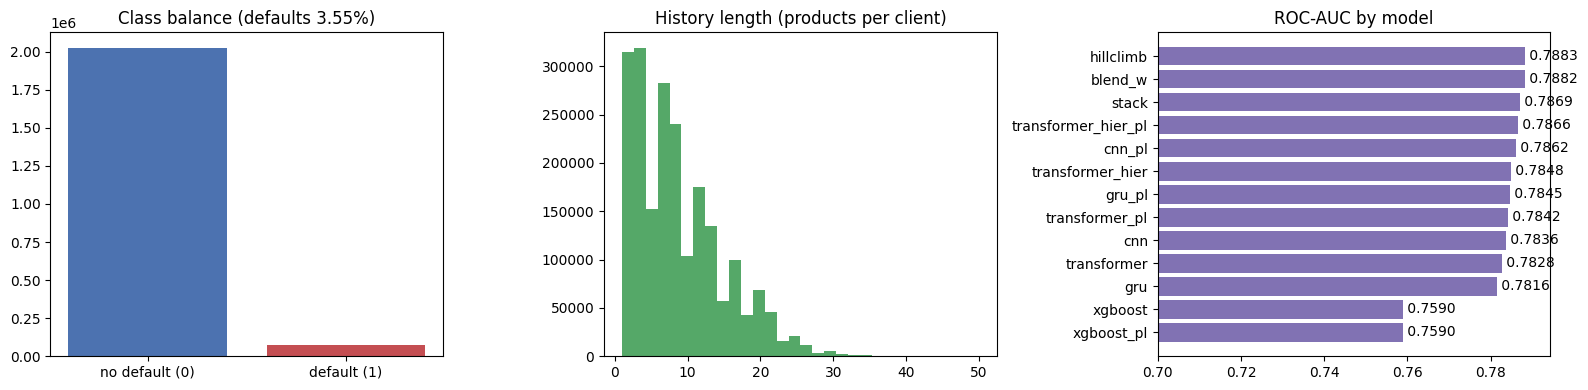

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

counts = pd.Series(y).value_counts().sort_index()
ax[0].bar(['no default (0)', 'default (1)'], counts.values, color=['#4c72b0', '#c44e52'])
ax[0].set_title(f'Class balance (defaults {float(y.mean()) * 100:.2f}%)')

ax[1].hist(np.clip(tr_cnt, 0, MAX_LEN), bins=30, color='#55a868')
ax[1].set_title('History length (products per client)')

ranked = dict(sorted(scores.items(), key=lambda item: item[1]))
ax[2].barh(list(ranked.keys()), list(ranked.values()), color='#8172b3')
ax[2].set_xlim(0.70, max(scores.values()) + 0.006)
ax[2].set_title('ROC-AUC by model')
for i, value in enumerate(ranked.values()):
    ax[2].text(value, i, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()

## Формирование ответа

In [48]:
submission = pd.read_csv(SUB)
submission['flag'] = submission['id'].map(pd.Series(FINAL_TEST, index=ids_test))
n_missing = int(submission['flag'].isna().sum())
submission['flag'] = submission['flag'].fillna(float(y.mean()))
submission.to_csv(os.path.join(OUT, 'submission.csv'), index=False)

json.dump({n: round(float(v), 5) for n, v in scores.items()},
          open(os.path.join(OUT, 'results.json'), 'w'), indent=2, ensure_ascii=False)

assert len(submission) == 900000
assert submission['flag'].between(0, 1).all()
assert submission['flag'].isna().sum() == 0
print(f'OK -> submission.csv | выбрано: {best} ({scores[best]:.5f}) | '
      f'без истории: {n_missing} | pred [{submission.flag.min():.3f}, {submission.flag.max():.3f}]')

OK -> submission.csv | выбрано: hillclimb (0.78835) | без истории: 0 | pred [0.000, 1.000]
